# Lab practice

In [41]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

## Load datasets

In [42]:
train_df = pd.read_csv('data/sent_train.csv')
valid_df = pd.read_csv('data/sent_valid.csv')

## Data Preparation

In [43]:
if 'text' not in train_df.columns:
    print("No se encontró la columna 'text'. Se renombrará la primera columna como 'text'.")
    train_df.rename(columns={train_df.columns[0]: 'text'}, inplace=True)
    valid_df.rename(columns={valid_df.columns[0]: 'text'}, inplace=True)

sentiment_column = 'label'
print("Columnas luego de ajustes:", train_df.columns)

aresentiments = {
    "LABEL_0": "Bearish", 
    "LABEL_1": "Bullish", 
    "LABEL_2": "Neutral"
}


Columnas luego de ajustes: Index(['text', 'label'], dtype='object')


In [44]:
# Check if the sentiment column in train_df is of object type
if train_df[sentiment_column].dtype == object:
    # Map the sentiment labels to integers by splitting the string and taking the last part
    train_labels_mapped = train_df[sentiment_column].map(lambda x: int(x.split('_')[-1]))
    valid_labels_mapped = valid_df[sentiment_column].map(lambda x: int(x.split('_')[-1]))
    
    # If there are any unmapped values in train_df, warn and filter out those rows
    if train_labels_mapped.isnull().sum() > 0:
        print("Warning: Unmapped values found in train_df. Removing rows with invalid labels.")
        mask = train_labels_mapped.notnull()
        train_df = train_df[mask]
        train_labels_mapped = train_labels_mapped[mask]
    
    # Similarly, if there are unmapped values in valid_df, warn and filter them out
    if valid_labels_mapped.isnull().sum() > 0:
        print("Warning: Unmapped values found in valid_df. Removing rows with invalid labels.")
        mask = valid_labels_mapped.notnull()
        valid_df = valid_df[mask]
        valid_labels_mapped = valid_labels_mapped[mask]
else:
    # If the sentiment column is already numeric, use it directly
    train_labels_mapped = train_df[sentiment_column]
    valid_labels_mapped = valid_df[sentiment_column]

# Convert the mapped labels to integer numpy arrays
train_labels = train_labels_mapped.astype(int).values
valid_labels = valid_labels_mapped.astype(int).values

# Define the number of classes
num_classes = 3

# Convert the integer labels to one-hot encoded vectors
train_labels_cat = to_categorical(train_labels, num_classes=num_classes)
valid_labels_cat = to_categorical(valid_labels, num_classes=num_classes)

# Get the target names from the aresentiments dictionary
target_names = [aresentiments["LABEL_0"], aresentiments["LABEL_1"], aresentiments["LABEL_2"]]

## Tokenize and Pad Text Sequences

In [45]:
vocab_size = 10000  
oov_token = "<OOV>"

# Initialize the tokenizer and fit it on the training texts
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(train_df['text'])

# Convert texts into numerical sequences
train_sequences = tokenizer.texts_to_sequences(train_df['text'])
valid_sequences = tokenizer.texts_to_sequences(valid_df['text'])

# Define the maximum sequence length and apply padding
max_length = 50
train_padded = pad_sequences(
    train_sequences, maxlen=max_length, 
    padding='post', truncating='post'
)
valid_padded = pad_sequences(
    valid_sequences, maxlen=max_length,
    padding='post', truncating='post'
)


## Model

In [46]:
embedding_dim = 100  # Dimensionality of the embedding representation

model = Sequential()
# Embedding layer (omitting 'input_length' as it is deprecated)
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))
# LSTM layer with dropout for regularization
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
# Output layer with softmax activation for 3 classes
model.add(Dense(num_classes, activation='softmax'))

# Compile the model with categorical cross-entropy loss and the Adam optimizer
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Display the summary of the model
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Evaluation metrics

In [47]:
val_loss, val_accuracy = model.evaluate(valid_padded, valid_labels_cat)
print("\nPérdida en validación:", val_loss)
print("Precisión en validación:", val_accuracy)

# Realizamos predicciones en el conjunto de validación.
predictions = model.predict(valid_padded)
predicted_labels = predictions.argmax(axis=1)

# Mostramos un reporte de clasificación utilizando los nombres de clase definidos.
print("\nReporte de clasificación en validación:")
print(classification_report(valid_labels, predicted_labels, target_names=target_names))

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6285 - loss: 1.0944

Pérdida en validación: 1.093902349472046
Precisión en validación: 0.6557788848876953
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Reporte de clasificación en validación:
              precision    recall  f1-score   support

     Bearish       0.00      0.00      0.00       347
     Bullish       0.00      0.00      0.00       475
     Neutral       0.66      1.00      0.79      1566

    accuracy                           0.66      2388
   macro avg       0.22      0.33      0.26      2388
weighted avg       0.43      0.66      0.52      2388



/home/santi/anaconda3/envs/lab/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/santi/anaconda3/envs/lab/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/santi/anaconda3/envs/lab/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

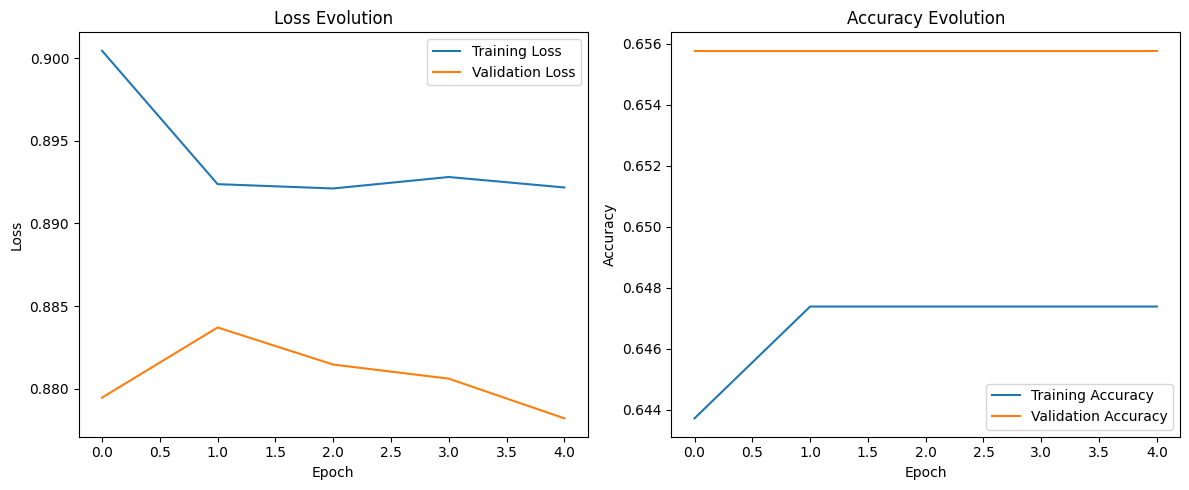

In [48]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Evolution')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Evolution')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()